In [9]:
import cv2
import numpy as np

def gaussian_pyramid(image, levels):
    pyramid = [image]
    for i in range(levels):
        image = cv2.pyrDown(image)
        pyramid.append(image)
    return pyramid

def laplacian_pyramid(gaussian_pyramid):
    laplacian_pyramid = []
    for i in range(len(gaussian_pyramid) - 1):
        size = (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0])
        expanded = cv2.pyrUp(gaussian_pyramid[i + 1], dstsize=size)
        laplacian = cv2.subtract(gaussian_pyramid[i], expanded)
        laplacian_pyramid.append(laplacian)
    laplacian_pyramid.append(gaussian_pyramid[-1])  # Add the smallest level
    return laplacian_pyramid

def pyramid_blend(A, B, levels, mask):
    # ---------- 智能归一化（修复双重归一化问题） ----------
    # 如果 mask 是 uint8 类型，归一化到 0~1
    # 如果 mask 已经是 float32 但值在 0~255 之间（比如不小心忘记归一化），也归一化
    # 如果 mask 已经是 float32 且值在 0~1 之间，保持不变
    if mask.dtype == np.uint8:
        mask = mask.astype(np.float32) / 255.0
    else:
        mask = mask.astype(np.float32)
        if np.max(mask) > 1.0:
            mask = mask / 255.0
    # 此时 mask 一定在 [0.0, 1.0] 范围内

    gpA = gaussian_pyramid(A, levels)
    gpB = gaussian_pyramid(B, levels)
    lpA = laplacian_pyramid(gpA)
    lpB = laplacian_pyramid(gpB)
    gpMask = gaussian_pyramid(mask, levels)

    blend_pyramid = []
    for i in range(levels + 1):
        m = gpMask[i]
        if m.ndim == 2:
            m = m[..., np.newaxis]  # 扩展维度，便于广播

        blended = lpA[i] * m + lpB[i] * (1.0 - m)
        blend_pyramid.append(blended)

    blended_image = blend_pyramid[-1]
    for i in range(levels, 0, -1):
        blended_image = cv2.pyrUp(blended_image)
        h, w = blend_pyramid[i - 1].shape[:2]
        blended_image = blended_image[:h, :w]
        blended_image = blended_image + blend_pyramid[i - 1]

    return np.clip(blended_image, 0, 255).astype(np.uint8)

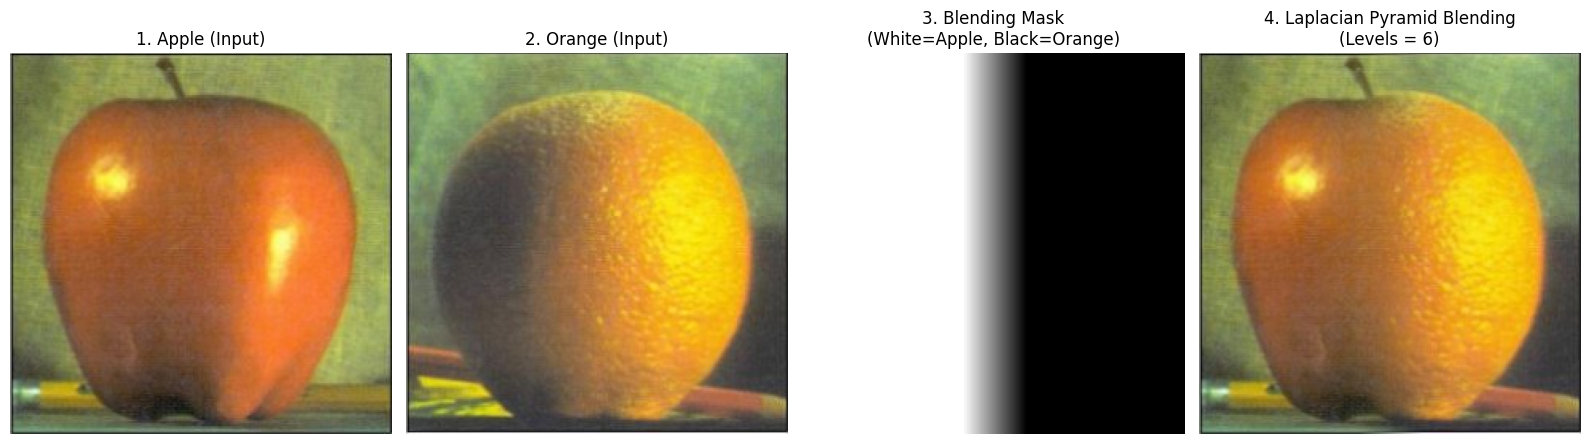

融合图像尺寸: (240, 240, 3)
数据类型: uint8


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==================== 1. 图像加载与预处理 ====================

# 请修改为你的图片实际存放路径
apple_path = r"C:\ZC\HIT\Compulsory_Courses\CV\CV_lab\mine\lab1\data\apple.png"   
orange_path = r"C:\ZC\HIT\Compulsory_Courses\CV\CV_lab\mine\lab1\data\orange.png" 

# 读取图像（OpenCV 默认 BGR 格式）
apple = cv2.imread(apple_path)
orange = cv2.imread(orange_path)

# 如果图片不存在，程序会报错提示
if apple is None or orange is None:
    raise FileNotFoundError("请检查图片路径是否正确！")

# 统一尺寸（以两张图中较小的尺寸为准，或者手动指定）
h = min(apple.shape[0], orange.shape[0])
w = min(apple.shape[1], orange.shape[1])
apple = cv2.resize(apple, (w, h))
orange = cv2.resize(orange, (w, h))

# 转为 float32 类型（非常重要！防止拉普拉斯残差因 uint8 截断而丢失细节）
apple = apple.astype(np.float32)
orange = orange.astype(np.float32)

# ==================== 2. 生成渐变掩码 (Mask) ====================

def create_mask(shape, blend_width=30):
    h, w = shape[0], shape[1]
    mask = np.zeros((h, w), dtype=np.float32)
    start = w // 2 - blend_width // 2
    end = w // 2 + blend_width // 2
    for j in range(w):
        if j < start:
            mask[:, j] = 1.0
        elif j > end:
            mask[:, j] = 0.0
        else:
            ratio = (end - j) / blend_width
            mask[:, j] = ratio
    return mask   # 返回 (h, w) 二维数组

mask = create_mask(apple.shape, blend_width=40)

# ==================== 3. 金字塔构建与融合（调用你之前写的函数） ====================



levels = 6  # 金字塔层数（6层足够产生平滑融合）
blended_result = pyramid_blend(apple, orange, levels, mask)

# ==================== 4. 可视化对比 ====================

# 将图像转回 uint8 供 matplotlib 显示（并转换 BGR -> RGB）
apple_show = cv2.cvtColor(apple.astype(np.uint8), cv2.COLOR_BGR2RGB)
orange_show = cv2.cvtColor(orange.astype(np.uint8), cv2.COLOR_BGR2RGB)
result_show = cv2.cvtColor(blended_result.astype(np.uint8), cv2.COLOR_BGR2RGB)

# 掩码可视化（灰度图转伪彩映射，便于观察）
mask_show = (mask.squeeze() * 255).astype(np.uint8)

plt.figure(figsize=(16, 6))

plt.subplot(1, 4, 1)
plt.imshow(apple_show)
plt.title('1. Apple (Input)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(orange_show)
plt.title('2. Orange (Input)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(mask_show, cmap='gray')
plt.title('3. Blending Mask\n(White=Apple, Black=Orange)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(result_show)
plt.title(f'4. Laplacian Pyramid Blending\n(Levels = {levels})')
plt.axis('off')

plt.tight_layout()
plt.show()

# 可选：在控制台打印融合图尺寸和数据类型，便于调试
print(f"融合图像尺寸: {blended_result.shape}")
print(f"数据类型: {blended_result.dtype}")